In [17]:
from google.colab import files
uploaded = files.upload()

Saving archive (2).zip to archive (2) (1).zip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("archive (2).zip")

df.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232725 entries, 0 to 232724
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             232725 non-null  object 
 1   artist_name       232725 non-null  object 
 2   track_name        232724 non-null  object 
 3   track_id          232725 non-null  object 
 4   popularity        232725 non-null  int64  
 5   acousticness      232725 non-null  float64
 6   danceability      232725 non-null  float64
 7   duration_ms       232725 non-null  int64  
 8   energy            232725 non-null  float64
 9   instrumentalness  232725 non-null  float64
 10  key               232725 non-null  object 
 11  liveness          232725 non-null  float64
 12  loudness          232725 non-null  float64
 13  mode              232725 non-null  object 
 14  speechiness       232725 non-null  float64
 15  tempo             232725 non-null  float64
 16  time_signature    23

In [7]:
features = df[['danceability',
               'energy',
               'loudness',
               'speechiness',
               'acousticness',
               'instrumentalness',
               'liveness',
               'valence',
               'tempo']]

features.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0.389,0.910,-1.828,0.0525,0.611,0.000,0.3460,0.814,166.969
1,0.590,0.737,-5.559,0.0868,0.246,0.000,0.1510,0.816,174.003
2,0.663,0.131,-13.879,0.0362,0.952,0.000,0.1030,0.368,99.488
3,0.240,0.326,-12.178,0.0395,0.703,0.000,0.0985,0.227,171.758
4,0.331,0.225,-21.150,0.0456,0.950,0.123,0.2020,0.390,140.576


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [10]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

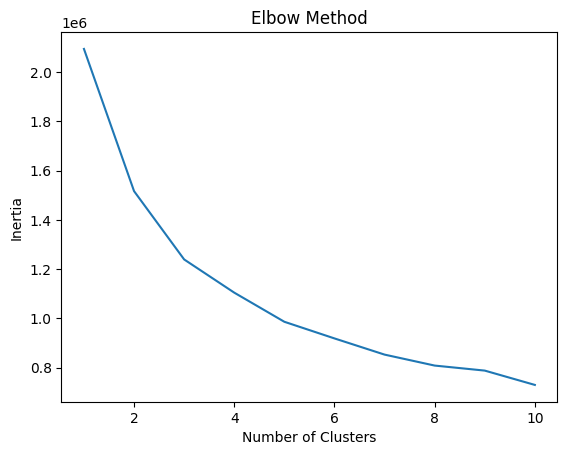

In [11]:
plt.plot(range(1,11), inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [12]:
kmeans = KMeans(n_clusters=5, random_state=42)

df['cluster'] = kmeans.fit_predict(scaled_features)

df.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,cluster
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814,4
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816,4
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368,0
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227,0
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390,0


In [22]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_features)

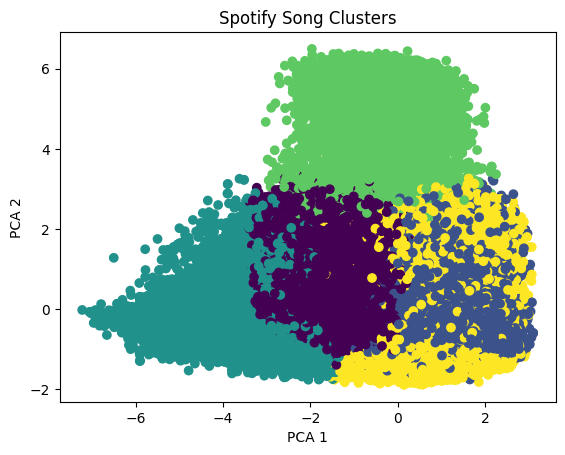

In [25]:
plt.scatter(pca_features[:,0], pca_features[:,1], c=df['cluster'], cmap='viridis')
plt.title("Spotify Song Clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [26]:
sample_df = df.sample(5000, random_state=42)
sample_features = scaled_features[sample_df.index]
sample_clusters = sample_df['cluster']

In [27]:
from sklearn.metrics import silhouette_score

score = silhouette_score(sample_features, sample_clusters)

print("Silhouette Score:", round(score,4))

Silhouette Score: 0.1966


In [29]:
print("\n================ MUSIC CLUSTERING PROJECT SUMMARY ================\n")

dataset_size = len(df)

# Calculate the variance explained by the two PCA components
variance = sum(pca.explained_variance_ratio_) * 100

print(f"Dataset size       : {dataset_size:,} songs")
print("Features used      : danceability, energy, tempo, loudness, valence")
print("Algorithm          : KMeans (K=5)")
print(f"Silhouette Score   : {score:.4f}")
print(f"PCA Variance (2D)  : {variance:.2f}%")


================ MUSIC CLUSTERING PROJECT SUMMARY ================

Dataset size       : 232,725 songs
Features used      : danceability, energy, tempo, loudness, valence
Algorithm          : KMeans (K=5)
Silhouette Score   : 0.1966
PCA Variance (2D)  : 56.34%
